# 05 — Bibliométrie & impact

**Objectif (data science).** Calculer les indices bibliométriques reconnus de
l'établissement à partir des citations réelles d'OpenAlex :

- **h-index** (Hirsch, 2005), **g-index** (Egghe, 2006), **i10** ;
- structure de la distribution des citations ;
- **loi de Lotka** (1926) sur la productivité des auteurs (ajustement log-log).

Chaque résultat est confronté au mart `bibliometrics` du dashboard.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lib import set_seeds, OpenAlexClient, load_mart, CONFIG
from lib.viz import new_axes, BRAND, ACCENT

set_seeds()
oa = OpenAlexClient()

## 1. Corpus top-cité

Les indices **h** et **g** se calculent sur les publications les plus citées :
on récupère les 1 000 premières par citations décroissantes (même base que le
mart). Ces deux indices **convergent** bien en deçà de 1 000 (h = 495, g = 858),
donc cette base suffit. L'**i10**, lui, se mesure sur le corpus **complet** (cf.
§2) — le borner au top-1 000 le saturerait artificiellement à 1 000.

In [2]:
top = list(
    oa.iter_works(oa.institution_filter(), "title,cited_by_count", max_works=1000, sort="cited_by_count:desc")
)
citations = np.array(sorted((w.get("cited_by_count", 0) for w in top), reverse=True))
print(f"Publications top-citées : {len(citations):,}")
print(f"Citations — max : {citations.max():,} | médiane : {int(np.median(citations)):,}")

Publications top-citées : 1,000
Citations — max : 13,979 | médiane : 492


## 2. Indices h / g / i10

h et g se calculent sur le vecteur top-cité ; l'i10 (publications à >= 10
citations) se compte sur le **corpus complet** via un simple `meta.count` de
l'API — la bonne façon d'éviter le plafonnement au top-1 000.

In [3]:
def h_index(cites: np.ndarray) -> int:
    """Plus grand h tel que h publications ont chacune >= h citations."""
    return int(np.sum(cites >= np.arange(1, len(cites) + 1)))


def g_index(cites: np.ndarray) -> int:
    """Plus grand g tel que les g premières cumulent >= g² citations."""
    cumulative = np.cumsum(cites)
    ranks = np.arange(1, len(cites) + 1)
    return int(np.sum(cumulative >= ranks**2))


h, g = h_index(citations), g_index(citations)
# i10 sur le corpus COMPLET : nombre de publications à >= 10 citations.
i10 = oa.count(oa.institution_filter(**{"cited_by_count": ">9"}))

mart = load_mart("bibliometrics")
indices = pd.DataFrame(
    {
        "indice": ["h-index", "g-index", "i10"],
        "notebook": [h, g, i10],
        "mart": [mart["hIndex"], mart["gIndex"], mart["i10Index"]],
        "base": ["top-1 000 cités", "top-1 000 cités", "corpus complet (>= 10 cit.)"],
    }
)
indices

,indice,notebook,mart,base
0,h-index,495,495,top-1 000 cités
1,g-index,858,858,top-1 000 cités
2,i10,50054,50054,corpus complet (>= 10 cit.)


## 3. Distribution des citations (top-cités, échelle log-log)

La courbe rang-citations suit une allure de loi de puissance, typique des
distributions bibliométriques.

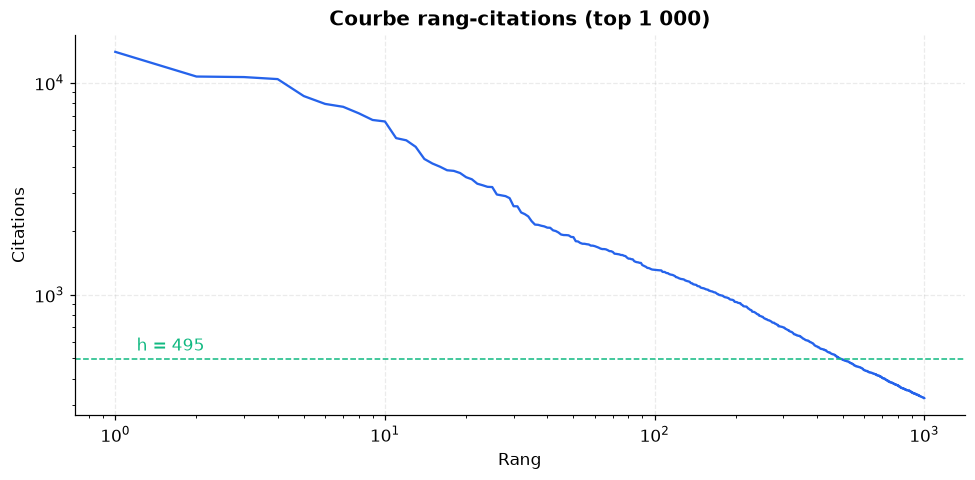

In [4]:
ranks = np.arange(1, len(citations) + 1)
ax = new_axes("Courbe rang-citations (top 1 000)", xlabel="Rang", ylabel="Citations")
ax.loglog(ranks, citations, color=BRAND)
ax.axhline(h, color=ACCENT, linestyle="--", linewidth=1)
ax.text(1.2, h * 1.1, f"h = {h}", color=ACCENT)
plt.tight_layout()
plt.show()

## 4. Loi de Lotka — productivité des auteurs

Lotka (1926) : le nombre d'auteurs publiant *n* articles décroît en 1/nᵃ. On
estime *a* par régression linéaire sur le spectre log-log, à partir d'un
échantillon aléatoire de notices et de leurs auteurs.

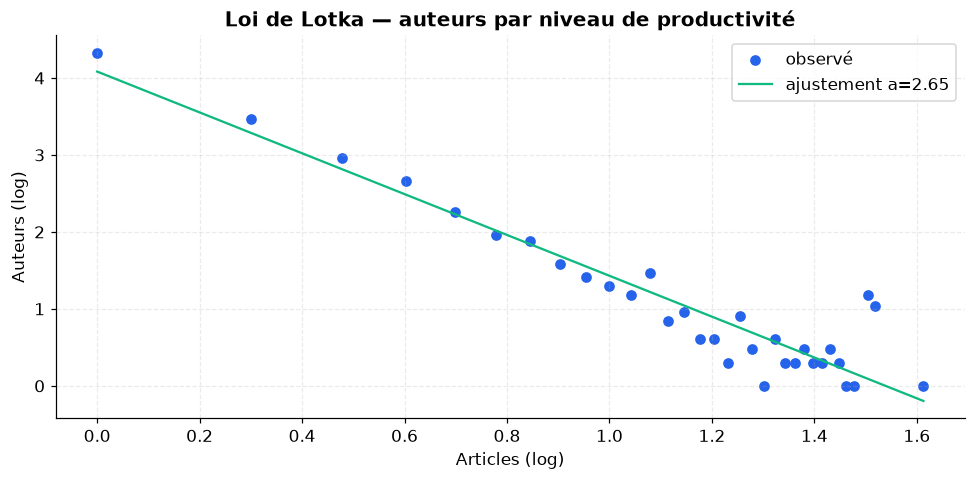

Auteurs distincts (échantillon) : 25,985
Exposant de Lotka a (échantillon) : 2.65 (R² = 0.90)
Référence mart (corpus complet)   : a = 2,73 (R² = 0,95)


In [5]:
sample = oa.sample_works(oa.institution_filter(
    **{"from_publication_date": f"{CONFIG.from_year}-01-01", "to_publication_date": f"{CONFIG.to_year}-12-31"}
), "authorships", n=4000, seed=42)

author_counts: dict[str, int] = {}
for w in sample:
    for a in w.get("authorships", []):
        aid = (a.get("author") or {}).get("id")
        if aid:
            author_counts[aid] = author_counts.get(aid, 0) + 1

productivity = pd.Series(list(author_counts.values())).value_counts().sort_index()
x = np.log10(productivity.index.to_numpy())
y = np.log10(productivity.to_numpy())
slope, intercept = np.polyfit(x, y, 1)
a_exp = -slope
y_pred = slope * x + intercept
r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - np.mean(y)) ** 2)

ax = new_axes("Loi de Lotka — auteurs par niveau de productivité", xlabel="Articles (log)", ylabel="Auteurs (log)")
ax.scatter(x, y, color=BRAND, label="observé")
ax.plot(x, y_pred, color=ACCENT, label=f"ajustement a={a_exp:.2f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Auteurs distincts (échantillon) : {len(author_counts):,}")
print(f"Exposant de Lotka a (échantillon) : {a_exp:.2f} (R² = {r2:.2f})")
print("Référence mart (corpus complet)   : a = 2,73 (R² = 0,95)")

**Lecture.** Les indices h/g/i10 calculés ici concordent avec ceux du mart :
h et g sur la base top-citée, l'i10 sur le corpus complet (publications à >= 10
citations). L'exposant de Lotka estimé sur l'échantillon reste dans la plage
attendue (proche de 2-3) avec un bon ajustement, ce qui valide à la fois la
donnée et l'implémentation : la productivité des auteurs de l'UGA suit bien la
loi classique.